### Load 2D data file in SASView

2D fit with cylinder model
* no structure factor
* two angular distributions along $\delta_1$ and $\delta_2$

TO DO next:
* add a rectangular region to mask the structure factor peaks
* compare with 1D fiting of the same image
* compare with azimuthal fit profiles
* add calculation of S the order parameter from the angular distribution

developpement in SASView:
* go for qx, qy, qz data
* code a cylinder model for uniaxial distribution: angular distribution along $\delta_1$ + uniform distribution along $\delta_3$
* add Maier-Saupe distribution in the weights.py file

run using global (Python 3.12.10) on PC fixe 

import all the packages

In [1]:
import numpy as np

# import sasmodels
import sasmodels
import sasmodels.core
import sasmodels.data
import sasmodels.bumps_model

import sasdata

from sasdata.dataloader.loader import Loader
from sasmodels.data import load_data
#from sas import sascalc.dataloader

from sasmodels.data import plot_theory

import bumps
import bumps.fitters
import bumps.names
import bumps.fitproblem

import os



add Maier-Saupe distribution in the weights

In [2]:
import sasmodels.weights
sasmodels.weights.load_weights('maier_saupe.py')
sasmodels.weights.load_weights('maier_saupe_eq.py')

In [3]:

"""
import matplotlib.pyplot and set custom default settings for plots
"""
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')


import matplotlib.pyplot as plt
#from IPython.display import set_matplotlib_formats
#set_matplotlib_formats('svg')

plt.rc('font', size=14) # default fontsize
plt.rc('axes', titlesize=16)
plt.rc('axes', labelsize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
plt.rc('legend', title_fontsize=14)
plt.rc('figure', titlesize=18)
plt.rc("figure", figsize=(5,5))
plt.rc("lines", linewidth=3)

#import tol_colors as tc # colorblind safe color palettes

# use colorblind safe colors:
#plt.rc('axes', prop_cycle=plt.cycler('color', list(tc.tol_cset('muted'))))
#try:
#    plt.cm.register_cmap('tc_iridescent', tc.tol_cmap('iridescent'))
#except:
#    pass

#plt.rc('image', cmap='tc_iridescent')

#plt.rc('image', cmap='rainbow')
plt.rc('image', cmap='jet')



### file selection

nematic phase under E field SWING data
* .dat file obtained from SAXSProcessor by Nicolas

In [4]:
filename="./images/Isotropic/sasview_exports/160V_236.dat"
#filename="./SWING-data/E-field-nematic/1V_191.dat"


### data loader method

In [5]:

data2d=sasmodels.data.load_data(filename)

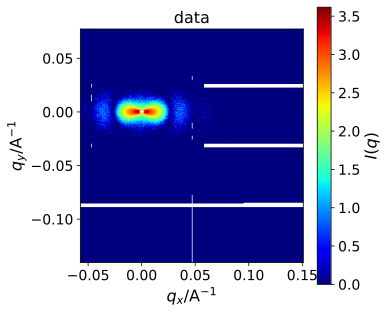

In [6]:
sasmodels.data.plot_data(data2d)

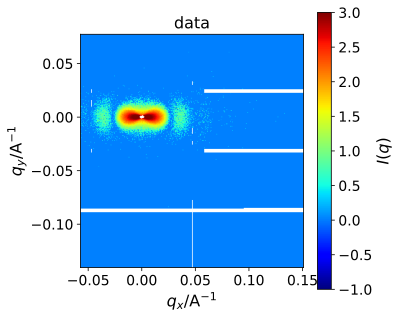

In [7]:
sasmodels.data.plot_data(data2d,view='log',limits=[0.1,1000])

#limits in intensity.

* store in I_all, qx_all and qy_all

In [8]:
I_all=data2d.data
#all intensity value sin data2d...
qx_all=data2d.qx_data
qy_all=data2d.qy_data

In [9]:
#I_error=data2d.errors

* rebuilt a data set

In [9]:
data_all = sasmodels.data.Data2D(x=qx_all, y=qy_all, z=I_all,dx=None,dy=None,dz=None)

#dx, dy, dz None, no errors

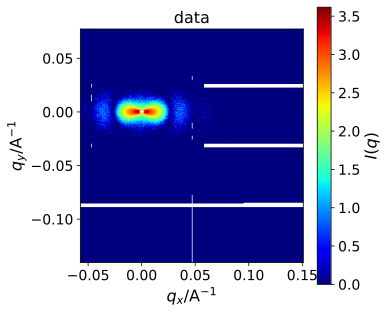

In [10]:
sasmodels.data.plot_data(data_all)

### reduce the number of data points before fiting

TO DO: add a circle in the middle to exclude the beamstop region

* create a numpy array
* ROI with qmax_x and qmax_y
* add a I_min value to avoir data points equal to zero  ... 
* errors proportionnal to intensity values (usually 10%)
* USE slicing=1 for a nice output with all data points in the ROI

89655
2989


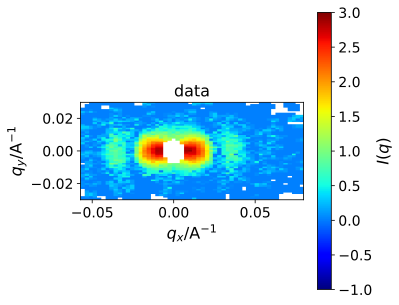

In [11]:
number_all=I_all.shape[0]

data_np=[]

# minvalue for data2d
I_min=0.0001

#error coefficient I*coefficient 
error_coeff=0.05
#error_min=0.000000

#ROI
qmax_x=0.08
qmax_y=0.03

#exclude a circle around the beamstop

q_center=0.01
#mask center radius...

#rectangular mask:

qmax_x_R=0.015
qmax_y_R=0.005

for i in range(number_all):
    if I_all[i]> I_min and (-qmax_x)<qx_all[i]<qmax_x and (-qmax_y)<qy_all[i]<qmax_y and (qx_all[i]**2+qy_all[i]**2)>q_center**2 :
#    print(I_all[i])
        data_np.append([qx_all[i],qy_all[i],I_all[i],error_coeff*I_all[i]])

data_np=np.array(data_np) 

size=data_np.shape[0]


print(size)

#slicing equal to one for keeping all data points in the ROI
#slicing=20
slicing=30

data_reduced_ROI = sasmodels.data.Data2D(x=data_np[0:size:slicing,0], 
                                     y=data_np[0:size:slicing,1], 
                                     z=data_np[0:size:slicing,2],
                                     dx=None,dy=None,
                                     dz=data_np[0:size:slicing,3])

sasmodels.data.plot_data(data_reduced_ROI,view="log",limits=[0.1,1000])
size_reduced=data_np[0:size:slicing,0].shape[0]
print(size_reduced)

In [14]:
print(data_reduced_ROI.data)

[1. 2. 2. ... 2. 3. 1.]


### fiting of the reduced set of data points in the image

* choice of the elliptical cylinder model 
* can be replaced by any other model !

In [12]:
kernel = sasmodels.core.load_model("elliptical_cylinder")
params = {} # default parameters for now, parameters...
model = sasmodels.bumps_model.Model(kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data_reduced_ROI, model=model)

## Gaussian

<Figure size 1000x500 with 0 Axes>

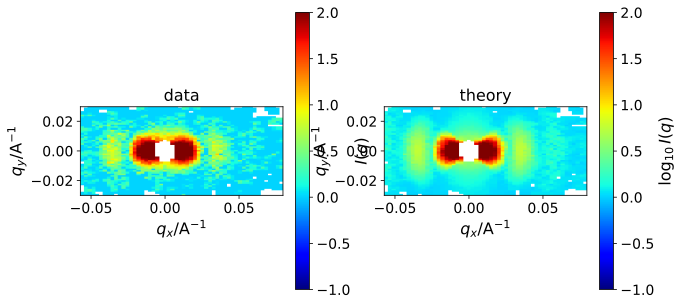

In [33]:
params = {
    "phi": 90, "theta": 90, "psi": 0,

    "theta_pd_type": 'gaussian', #polydispersity function
    "theta_pd": 17, #polydispersity
    "theta_pd_n": 100, #number of steps in polydispersity
    "theta_pd_nsigma": 3, #range of polydispersity

#    "phi_pd_type": 'uniform', #polydispersity function
#    "phi_pd": 90, #polydispersity
#    "phi_pd_n": 100, #number of steps in polydispersity

    "phi_pd_type": 'gaussian', #polydispersity function
    "phi_pd": 17, #polydispersity
    "phi_pd_n": 100, #number of steps in polydispersity
    "phi_pd_nsigma": 3, #range of polydispersity

#   "psi_pd_type": 'uniform', #polydispersity function
#    "psi_pd": 90, #polydispersity
#    "psi_pd_n": 20, #number of steps in polydispersity


    "axis_ratio": 1, # ratio for the elliptic crosssection, here for a cylinder 

    "radius_minor": 141, #radius of the NRs
    "radius_minor_pd_type": 'gaussian', #number of steps in polydispersity
    "radius_minor_pd": 0.06, #polydispersity
    "radius_minor_pd_n": 8, #number of steps in polydispersity
    "radius_minor_pd_nsigma": 4, #range of polydispersity

    "length":10000,

    "background": 1,
    "scale": 0.02
}
model = sasmodels.bumps_model.Model(model=kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data_reduced_ROI, model=model)

plt.figure(figsize=(10,5))



model = sasmodels.bumps_model.Model(model=kernel, **params)

#list of the fiting parameters with their fiting range
model.scale.range(0.005,0.1)
model.background.range(0.01,10)
model.theta_pd.range(15,20)
model.phi_pd.range(15,20)

#model.phi.range(70,120)
#model.theta.range(70,150)

#model.phi_pd.range(5, 10)
#model.theta_pd.range(5, 10)

#model.length.range(5000,20000)

#model.radius_minor.range(100,200)
#model.radius_pd.range(0.,0.1)

experiment = sasmodels.bumps_model.Experiment(data=data_reduced_ROI, model=model)

plt.figure(figsize=(10,5))
#experiment.plot()
plot_theory(data_reduced_ROI,experiment.theory(),view="log",limits=[0.1,100])

step 1 cost 145.6768(16)
                              background |.........          1 in [0.01, 10]
                                  phi_pd ...|......         17 in [15, 20]
                                   scale .|........       0.02 in [0.005, 0.1]
                                theta_pd ...|......         17 in [15, 20]
step 4 cost 96.5387(16)
step 7 cost 86.1568(16)
step 7 cost 86.1567(16) [final]
                              background |.........   0.832914 in [0.01, 10]
                                  phi_pd ...|......    16.9852 in [15, 20]
                                   scale |.........  0.0115272 in [0.005, 0.1]
                                theta_pd .........|         20 in [15, 20]
time 3.1 seconds
final chisq 86.1567(16)
=== Uncertainty from curvature:     name   value(unc.) ===
                              background   0.8329(17)     
                                  phi_pd   16.9852(44)    
                                   scale   0.011527(49)   
      

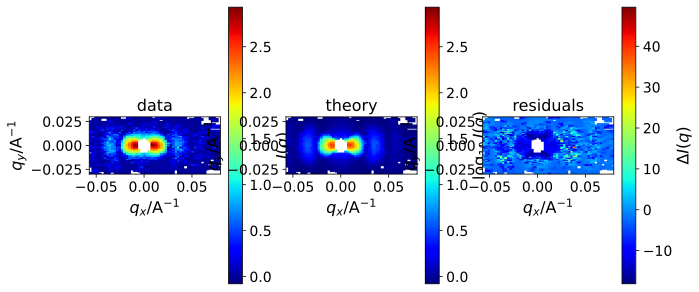

In [34]:
problem = bumps.fitproblem.FitProblem(experiment)

results = bumps.fitters.fit(problem, method='lm',steps=20, ftol=1.5e-08, xtol=1.5e-08, verbose=True)

plt.figure(figsize=(10, 5))
experiment.plot()

In [26]:
sigma_theta = model.theta_pd.value
print(sigma_theta)

61.22820720221202


In [27]:
sigma_phi = model.phi_pd.value
print(sigma_phi)

16.86116948201436


## Calculation of a Nematic order parameter

### Integration method:

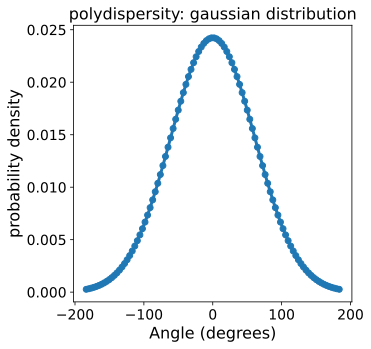

In [29]:
distribution = "gaussian"

# The probability density function can be accessed using the weights.get_weights() method in sasmodels
pdf = sasmodels.weights.get_weights(
    distribution,
    n=model.theta_pd_n.value,               # _pd_n parameter
    width=model.theta_pd.value,          # this is equal to _pd parameter, or sigma/x_mean
    nsigmas=model.theta_pd_nsigma.value,          # _pd_nsigma parameter
    value=model.theta.value,          # corresponds to x_mean, or the value of the parameter to which polydispersity is applied, in this case it is the radius
    limits=[-np.inf, np.inf], # hard limit on the possible values (can't have negative radius)
    relative=False       # set to true if width is in proportion to the parameter value, or x_mean in this case
)

plt.errorbar(pdf[0], pdf[1], fmt='o-')
plt.xlabel("Angle (degrees)")
plt.ylabel("probability density")
plt.title(f"polydispersity: {distribution} distribution")
plt.show()

In [1]:


from scipy import integrate

# Define a function
func = lambda x: x**3

# Calculate the definite integral of the function from 1 to 3
res,_ = integrate.quad(func, 1, 3)

# Print the result
print(res)

20.0


In [24]:
from scipy.integrate import quad
#define fucntion 

def func(sigma):
     func = lambda x: (3*np.cos(x)**2-1)*np.sin(x)*0.5*np.exp(-x**2/(2*sigma**2))
     norm = lambda x: np.sin(x)*0.5*np.exp(-x**2/(2*sigma**2))
     res_func, _ = quad(func,0,np.pi/2)
     res_norm,_ = quad(norm,0,np.pi/2)
     return res_func/res_norm

print(func(np.pi/20))


1.8578697251357592


In [31]:
from scipy.integrate import quad
#define fucntion 
func = lambda x: np.cos(x)**2*np.sin(x)
res, _ = quad(func,0,np.pi)

print(res)

0.6666666666666666


In [36]:
from scipy.integrate import quad
def compute_S_gaussian(sigma): # sigma and theta_0 are both in degrees
        """Compute nematic order parameter S from Gaussian parameters."""

        sigma_rad = np.pi*sigma/180

 
        num_integrand = lambda theta: (0.5 * (3*np.cos(theta))**2 - 1) * np.exp(-(theta)**2/(2*sigma_rad**2)) * np.sin(theta)
        den_integrand = lambda theta: np.exp(-(theta)**2/(2*sigma_rad**2)) * np.sin(theta)

        num, _ = quad(num_integrand, 0, np.pi, epsabs=1e-10, epsrel=1e-10)
        den, _ = quad(den_integrand, 0, np.pi, epsabs=1e-10, epsrel=1e-10)

        return num / den

print(compute_S_gaussian(49.82))

0.9108797271420516


In [30]:
import numpy as np
from scipy.integrate import quad

# --- Legendre polynomial P2 ---
def P2(theta):
    return 0.5 * (3 * np.cos(theta)**2 - 1)

# --- Gaussian distribution ---
def gaussian(theta, sigma):
    return np.exp(-theta**2 / (2 * sigma**2))

# --- Numerator integrand ---
def numerator_integrand(theta, sigma):
    return P2(theta) * gaussian(theta, sigma) * np.sin(theta)

# --- Denominator integrand ---
def denominator_integrand(theta, sigma):
    return gaussian(theta, sigma) * np.sin(theta)

# --- Nematic order parameter calculation ---
def nematic_order_parameter(sigma):
    numerator, _ = quad(numerator_integrand, 0, np.pi, args=(sigma,))
    denominator, _ = quad(denominator_integrand, 0, np.pi, args=(sigma,))
    return numerator / denominator

# Example usage

sigma_degree = 20 # width of angular distribution (degrees)
S = nematic_order_parameter(sigma_degree*np.pi/180)

print(f"Nematic Order Parameter S = {S:.5f}")


Nematic Order Parameter S = 0.69906


In [31]:
S = nematic_order_parameter(model.theta_pd.value*np.pi/180)

print(f"Nematic Order Parameter S = {S:.5f}")
print(sigma_theta)

Nematic Order Parameter S = 0.05747
61.22820720221202


In [32]:
S = nematic_order_parameter(model.phi_pd.value*np.pi/180)

print(f"Nematic Order Parameter S = {S:.5f}")
print(sigma_phi)

Nematic Order Parameter S = 0.77413
16.86116948201436


In [28]:
print(compute_S_gaussian(49))

0.9351345041495402


## Maier_saupe


first manual adjustement of different parameters

* choice of the initial values for parameters
* choice of the fiting parameters with their fiting range

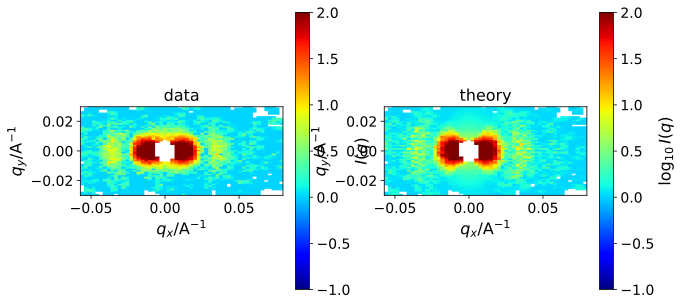

In [43]:
params = {
    "phi": 90, "theta": 90, "psi": 0,

    "theta_pd_type": 'maier_saupe', #polydispersity function
    "theta_pd": 5, #polydispersity
    "theta_pd_n": 40, #number of steps in polydispersity
    "theta_pd_nsigma": 3, #range of polydispersity

#    "phi_pd_type": 'uniform', #polydispersity function
#    "phi_pd": 90, #polydispersity
#    "phi_pd_n": 100, #number of steps in polydispersity

    "phi_pd_type": 'maier_saupe', #polydispersity function
    "phi_pd": 5, #polydispersity
    "phi_pd_n": 40, #number of steps in polydispersity
    "phi_pd_nsigma": 3, #range of polydispersity

#   "psi_pd_type": 'uniform', #polydispersity function
#    "psi_pd": 90, #polydispersity
#    "psi_pd_n": 20, #number of steps in polydispersity


    "axis_ratio": 1, # ratio for the elliptic crosssection, here for a cylinder 

    "radius_minor": 141, #radius of the NRs
    "radius_minor_pd_type": 'gaussian', #number of steps in polydispersity
    "radius_minor_pd": 0.06, #polydispersity
    "radius_minor_pd_n": 8, #number of steps in polydispersity
    "radius_minor_pd_nsigma": 4, #range of polydispersity

    "length":10000,

    "background": 1,
    "scale": 0.02
}

model = sasmodels.bumps_model.Model(model=kernel, **params)

#list of the fiting parameters with their fiting range
model.scale.range(0.005,0.1)
model.background.range(0.01,10)
#model.theta_pd.range(10,30)
#model.phi_pd.range(10,30)


model.phi_pd.range(1, 5)
model.theta_pd.range(0, 1)

#model.length.range(5000,20000)

#model.radius_minor.range(100,200)
#model.radius_pd.range(0.,0.1)

experiment = sasmodels.bumps_model.Experiment(data=data_reduced_ROI, model=model)

plt.figure(figsize=(10,5))
#experiment.plot()
plot_theory(data_reduced_ROI,experiment.theory(),view="log",limits=[0.1,100])

* creation of the fit `problem` 
* `problem` is generated by FitProblem in bump module
* RUN the fit problem

step 1 cost 374.6533(16)


c:\Users\kutalia\AppData\Local\Programs\Python\Python312\Lib\site-packages\bumps\fitproblem.py:631: UserWarning: Unsatisfied constraints: [theta_pd=5.0 is outside (0.0,1.0)]
  warnings.warn("Unsatisfied constraints: [%s]" % (",\n".join(broken)))


                              background |.........          1 in [0.01, 10]
                                  phi_pd .........|          5 in [1, 5]
                                   scale .|........       0.02 in [0.005, 0.1]
                                theta_pd .........|          1 in [0, 1]
step 10 cost 91.5770(16)
step 19 cost 91.2382(16) [final]
                              background |.........   0.907221 in [0.01, 10]
                                  phi_pd .........|    4.97506 in [1, 5]
                                   scale |......... 0.00585846 in [0.005, 0.1]
                                theta_pd |......... 8.67362e-19 in [0, 1]
time 2.2 seconds
final chisq 91.2382(16)
=== Uncertainty from curvature:     name   value(unc.) ===
                              background   0.9072(16)     
                                  phi_pd   4.9751(13)     
                                   scale   0.005858(16)   
                                theta_pd   0.00(10)e9     


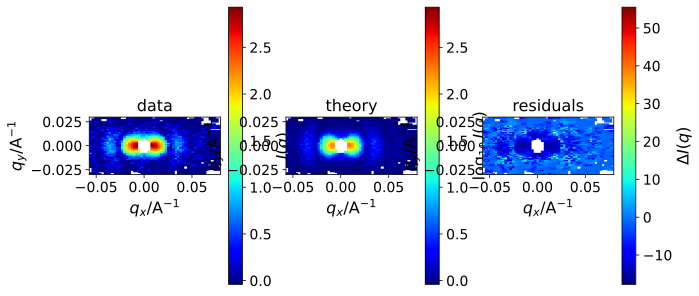

In [44]:
problem = bumps.fitproblem.FitProblem(experiment)

results = bumps.fitters.fit(problem, method='lm',steps=20, ftol=1.5e-08, xtol=1.5e-08, verbose=True)

plt.figure(figsize=(10, 5))
experiment.plot()

In [ ]:

print(model.phi_pd.value)

4.975064157695904


In [ ]:
def compute_S(m, x0):
        """Compute nematic order parameter S from Maier-Saupe parameters."""
        num_integrand = lambda theta: (0.5 * (3*np.cos(theta - np.radians(x0))**2 - 1)) \
                                    * np.exp(m*np.cos(theta - np.radians(x0))**2) * np.sin(theta)
        den_integrand = lambda theta: np.exp(m*np.cos(theta - np.radians(x0))**2) * np.sin(theta)

        num, _ = quad(num_integrand, 0, np.pi, epsabs=1e-10, epsrel=1e-10)
        den, _ = quad(den_integrand, 0, np.pi, epsabs=1e-10, epsrel=1e-10)

        return num / den


In [52]:
print(compute_S(5,0))

0.6463993319056482


In [33]:
print(problem.model_parameters())

{'models': [{'scale': Parameter(scale), 'background': Parameter(background), 'radius_minor': Parameter(radius_minor), 'radius_minor_pd': Parameter(radius_minor_pd), 'radius_minor_pd_n': Parameter(radius_minor_pd_n), 'radius_minor_pd_nsigma': Parameter(radius_minor_pd_nsigma), 'axis_ratio': Parameter(axis_ratio), 'axis_ratio_pd': Parameter(axis_ratio_pd), 'axis_ratio_pd_n': Parameter(axis_ratio_pd_n), 'axis_ratio_pd_nsigma': Parameter(axis_ratio_pd_nsigma), 'length': Parameter(length), 'length_pd': Parameter(length_pd), 'length_pd_n': Parameter(length_pd_n), 'length_pd_nsigma': Parameter(length_pd_nsigma), 'sld': Parameter(sld), 'sld_solvent': Parameter(sld_solvent), 'theta': Parameter(theta), 'theta_pd': Parameter(theta_pd), 'theta_pd_n': Parameter(theta_pd_n), 'theta_pd_nsigma': Parameter(theta_pd_nsigma), 'phi': Parameter(phi), 'phi_pd': Parameter(phi_pd), 'phi_pd_n': Parameter(phi_pd_n), 'phi_pd_nsigma': Parameter(phi_pd_nsigma), 'psi': Parameter(psi), 'psi_pd': Parameter(psi_pd), '

In [34]:
print(problem.summarize())

                              background |.........   0.884543 in [0.01, 10]
                            radius_minor ....|.....    141.042 in [100, 200]
                                   scale |......... 0.00826239 in [0.005, 0.1]


In [20]:
print(problem.chisq())

91.64643691655168


### plot after fiting

labels of the fiting parameters

In [21]:
problem.labels()

['background', 'radius_minor', 'scale']

fited values of the parameters

In [22]:
results.x

array([8.84536459e-01, 1.41045100e+02, 8.26260668e-03])

error of the fited values

In [23]:
results.dx

array([1.09972877e-03, 3.41572651e-02, 1.60749257e-05])

In [24]:
model.phi.value

90.0

In [25]:
model.scale.value

0.008262606675166055

In [26]:
model.radius_minor.value

141.04510002183326

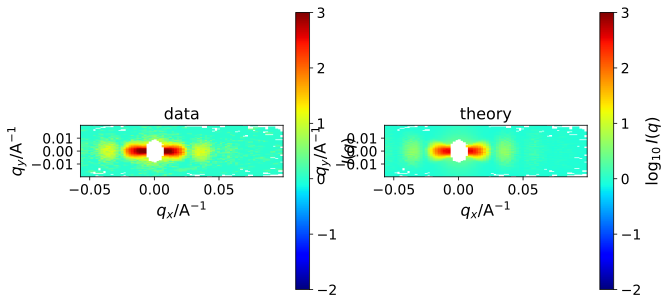

In [27]:
paramsfit = {
    "phi": model.phi.value, "theta": model.theta.value, "psi": model.psi.value,

    "theta_pd_type": 'maier_saupe', #polydispersity function
    "theta_pd": model.theta_pd.value, #polydispersity
    "theta_pd_n": model.theta_pd_n.value, #number of steps in polydispersity
    "theta_pd_nsigma": model.theta_pd_nsigma.value, #range of polydispersity

#    "phi_pd_type": 'uniform', #polydispersity function
#    "phi_pd": 90, #polydispersity
#    "phi_pd_n": 100, #number of steps in polydispersity

    "phi_pd_type": 'maier_saupe', #polydispersity function
    "phi_pd": model.phi_pd.value, #polydispersity
    "phi_pd_n": model.phi_pd_n.value, #number of steps in polydispersity
    "phi_pd_nsigma": model.phi_pd_nsigma.value, #range of polydispersity

#   "psi_pd_type": 'uniform', #polydispersity function
#    "psi_pd": 90, #polydispersity
#    "psi_pd_n": 20, #number of steps in polydispersity


    "axis_ratio": model.axis_ratio.value, # ratio for the elliptic crosssection, here for a cylinder 

    "radius_minor": model.radius_minor.value, #radius of the NRs
    "radius_minor_pd_type": 'gaussian', #number of steps in polydispersity
    "radius_minor_pd": model.radius_minor_pd.value, #polydispersity
    "radius_minor_pd_n": model.radius_minor_pd_n.value, #number of steps in polydispersity
    "radius_minor_pd_nsigma": model.radius_minor_pd_nsigma, #range of polydispersity

    "length":model.length.value,

    "background": model.background.value,
    "scale": model.scale.value
}

model = sasmodels.bumps_model.Model(model=kernel, **paramsfit)
experiment = sasmodels.bumps_model.Experiment(data=data_reduced_ROI, model=model)

plt.figure(figsize=(10,5))
#experiment.plot()
plot_theory(data_reduced_ROI,experiment.theory(),view="log",limits=[0.01,1000])

In [28]:
problem.fitness.theory()

c:\Users\Administrateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\bumps\fitproblem.py:305: UserWarning: Deprecated: use of problem.fitness will be removed at some point
  warnings.warn("Deprecated: use of problem.fitness will be removed at some point")


array([0.89121706, 0.92955719, 1.09591901, ..., 1.07439424, 0.98428704,
       0.93819185], shape=(6593,))

### cylinder model and orientation distribution:
* [cylinder model and angles](https://www.sasview.org/docs/user/models/cylinder.html)
* Angles θ and ϕ orient the cylinder relative to the beam line coordinates, where the beam is along the z axis. Rotation θ, initially in the xz plane, is carried out first, then rotation ϕ about the z axis. 
* Orientation distributions are described as rotations about two perpendicular axes δ1 and δ2 in the frame of the cylinder itself, which when θ=ϕ=0 are parallel to the Y and X axes.
* <img src="https://www.sasview.org/docs/_images/cylinder_angle_definition.png">
* <img src="https://www.sasview.org/docs/_images/cylinder_angle_projection.png">

### bumps for fiting
The default optimizer for the bumps fit is the Levenberg-Marquardt method, but there are many available as described in greater detail in the Bumps [documentation](https://bumps.readthedocs.io/en/latest/guide/optimizer.html) with additional fitting options.

For Levenberg-Marquardt, the steps, f(x) tolerance and x tolerance from the GUI options can be set with the `steps`, `ftol` and `xtol` arguments in the `fit` method.

<img src="https://bumps.readthedocs.io/en/latest/_images/fit-lm.png">

*Image source: https://bumps.readthedocs.io/en/latest/guide/optimizer.html*

### Explanation of the polydispersity parameters

The polydispersity is set using a special set of \*\_pd\_\* parameters:
* `*_pd*` is the width of the polydispersity and the exact definition will depend on the type of distribution specified; in this cause of a 'gaussian` distribution, it is defined as as $\frac{\sigma}{x_{mean}}$
* `*_pd_type*` defines the type of polydispersity distribution used
* `*_pd_n` corresponds to the the number of points in the distribution used by the calculation (Npts in the image below)
* `*_pd_nsigma` sets the range of the distribution sampled (Nsigmas in the image below)

For example, radius polydispersity could be defined by specifying **all four** of the pd parameters. With the default values, this would look like:
* `radius_pd = 0`
* `radius_pd_type = 'gaussian'`
* `radius_pd_n = 35`
* `radius_pd_nsigma = 3`

The available polydispersity distributions are defined in the SasView [documentation](https://www.sasview.org/docs/user/qtgui/Perspectives/Fitting/pd/polydispersity.html) but we can access them directly through the sasmodels `weights` module.

The 'gaussian' distribution is calculated by:

$$
f(x) = \frac{1}{Norm}\exp\left(-\frac{(x-x_{mean})^2}{2\sigma^2}\right)
$$

<img src=https://www.sasview.org/docs/_images/pd_gaussian.jpg>

*Image source: https://www.sasview.org/docs/user/qtgui/Perspectives/Fitting/pd/polydispersity.html*
